# Data science: data transformations and quantitative relationships

Visualization approaches are incredibly useful to convey meaningful relationships in data.
However, visualizations alone may be misleading in the sense that they can become purely qualitative, and thus ignore the quantitative relationships in data.
In this notebook, we will explore how data science can be quantitative, and not only qualitative.
This quantitative understanding draws on the ideas of statistics and relationships between the data formats.

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/01-DataScience"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In particular, we will discuss:

- **Data transformations**
- **Statistical significance**
- **Causation and correlation**
- **Correlation coefficients**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

df = pd.read_csv(f"{ROOT}/data/ptable.csv")

## Data transformations

Often, data has to be transformed in order to be analyzed properly.
In the real world, data is messy, and can come in a range of forms or have pronounced noise.
As a consequence, extracting insights from such varied data sources requires processing the data.
Here are a few examples on how or why processing the data makes sense.

### Changes of scale

One of the classic examples of materials science and chemistry is the Arrhenius equation, say, for the self-diffusion of an elemental crystal:

$$
D = D_0 \exp\left(
\frac{-E_a}{RT}
\right)
$$

Let's say that we want to visualize the self-diffusion of copper as a function of temperature. In Cu, the experimental values are $D_0 = 2.5 \times 10^{−5} \ \mathrm{m}^2/\mathrm{s}$ and $E_a = 200 \ \mathrm{kJ/mol}$. Furthermore, the gas constant is $R = 8.314 \ \mathrm{J/mol/K}$. Therefore, we can obtain the self-diffusion coefficient for copper as a function of temperature:

In [3]:
D0 = 2.5e-5
Ea = 200e3
R = 8.314
T = np.linspace(400, 1000)
D = D0 * np.exp(-Ea / (R * T))

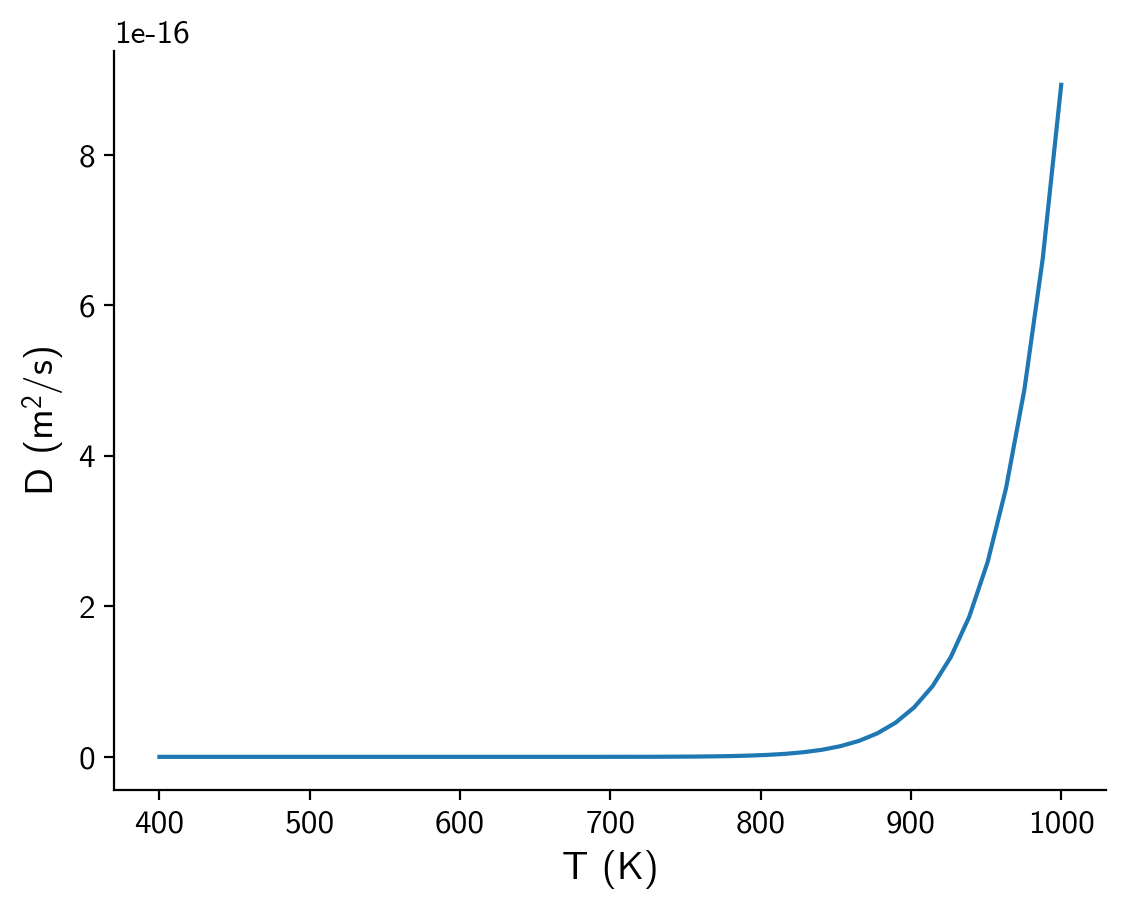

In [4]:
fig, ax = plt.subplots()

ax.plot(T, D)

ax.set_xlabel("T (K)")
ax.set_ylabel("D (m$^2$/s)")

plt.show()

The plot above shows that the relationship is exponential, as we expected.
However, in many cases, this plot is not useful.
Especially when comparing to experiments, the changes in diffusion coefficient happen along orders of magnitude across temperatures, but the plot above seems to imply that D is near-zero up until 800 K, which is not true.

The trick is to perform a data transformation when visualizing the data: instead of plotting $D$ vs $T$, we can plot $\log D$ vs $1 / T$ and obtain a linear relationship:

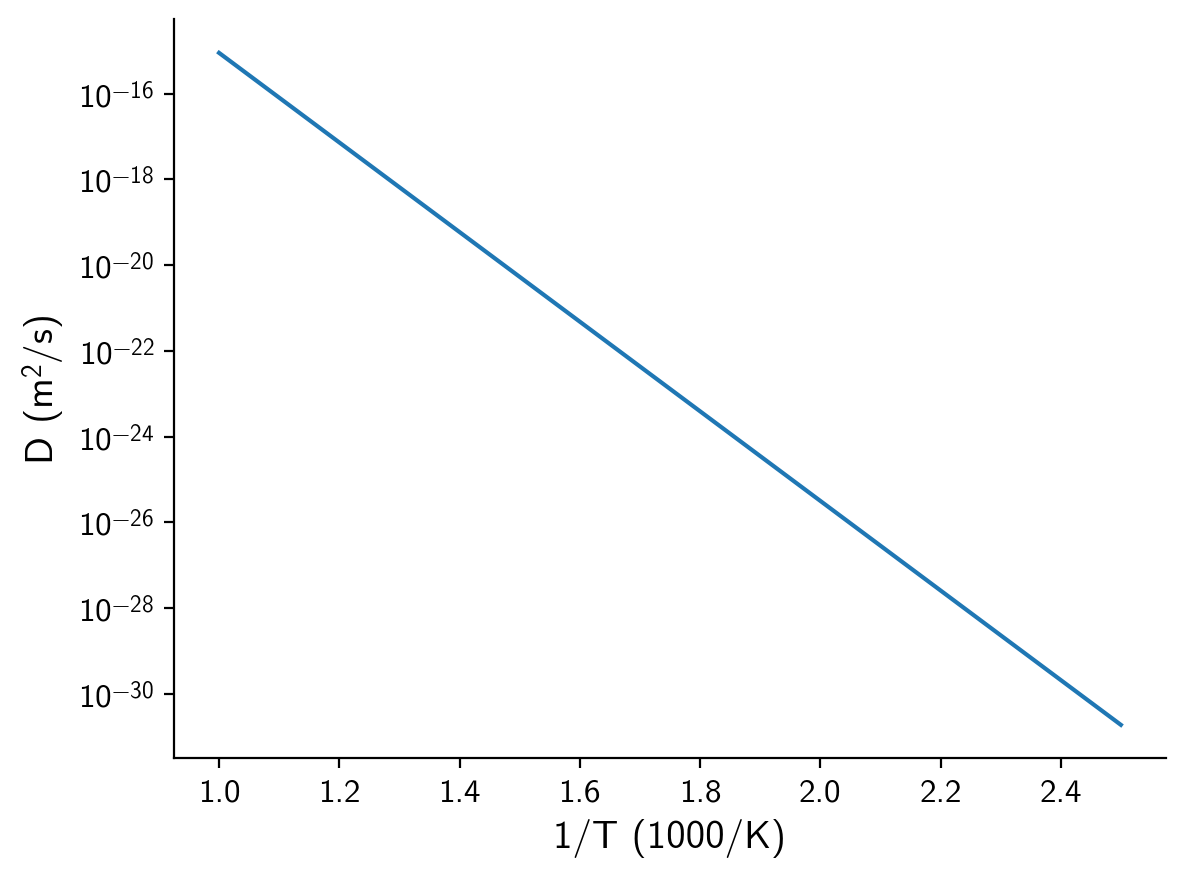

In [5]:
fig, ax = plt.subplots()

ax.plot(1000 / T, D)

ax.set_xlabel("1/T (1000/K)")
ax.set_ylabel("D (m$^2$/s)")

ax.set_yscale("log")

plt.show()

### Describing the data beforehand

As another example, we can analyze the previous dataset of the periodic table and notice that the heat capacity varies by orders of magnitude:

In [6]:
df["SpecificHeat"].describe()

count    85.000000
mean      0.635976
std       1.653965
min       0.094000
25%       0.168000
50%       0.244000
75%       0.489000
max      14.304000
Name: SpecificHeat, dtype: float64

If we wanted to plot, say, the correlation between the heat capacity and the density, we would have difficulty in extracting good insights from the data:

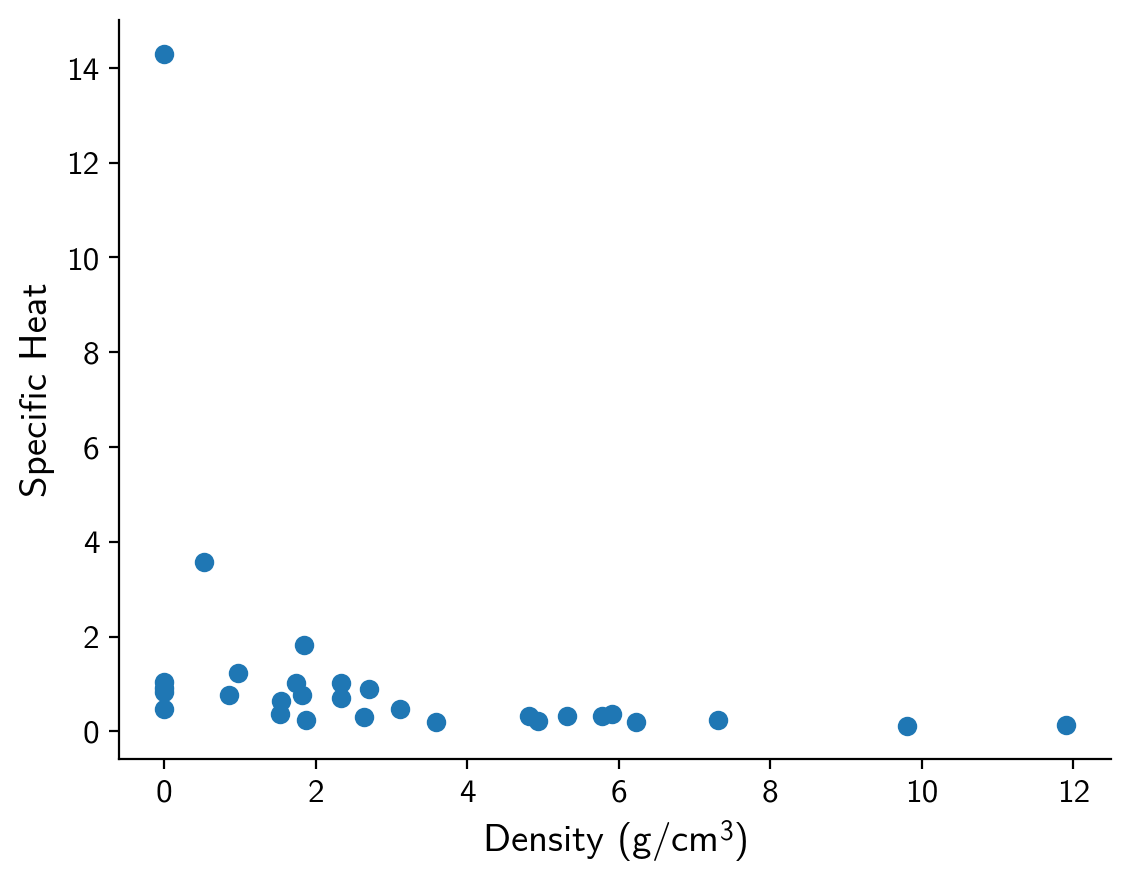

In [7]:
fig, ax = plt.subplots()

_df = df.dropna()

ax.scatter(_df["Density"], _df["SpecificHeat"])

ax.set_xlabel("Density (g/cm$^3$)")
ax.set_ylabel("Specific Heat")

plt.show()

A more adequate approach is to use a data transformation that spans the desired orders of magnitude for the specific heat, sometimes with the simple approach of changing the axes to a log plot:

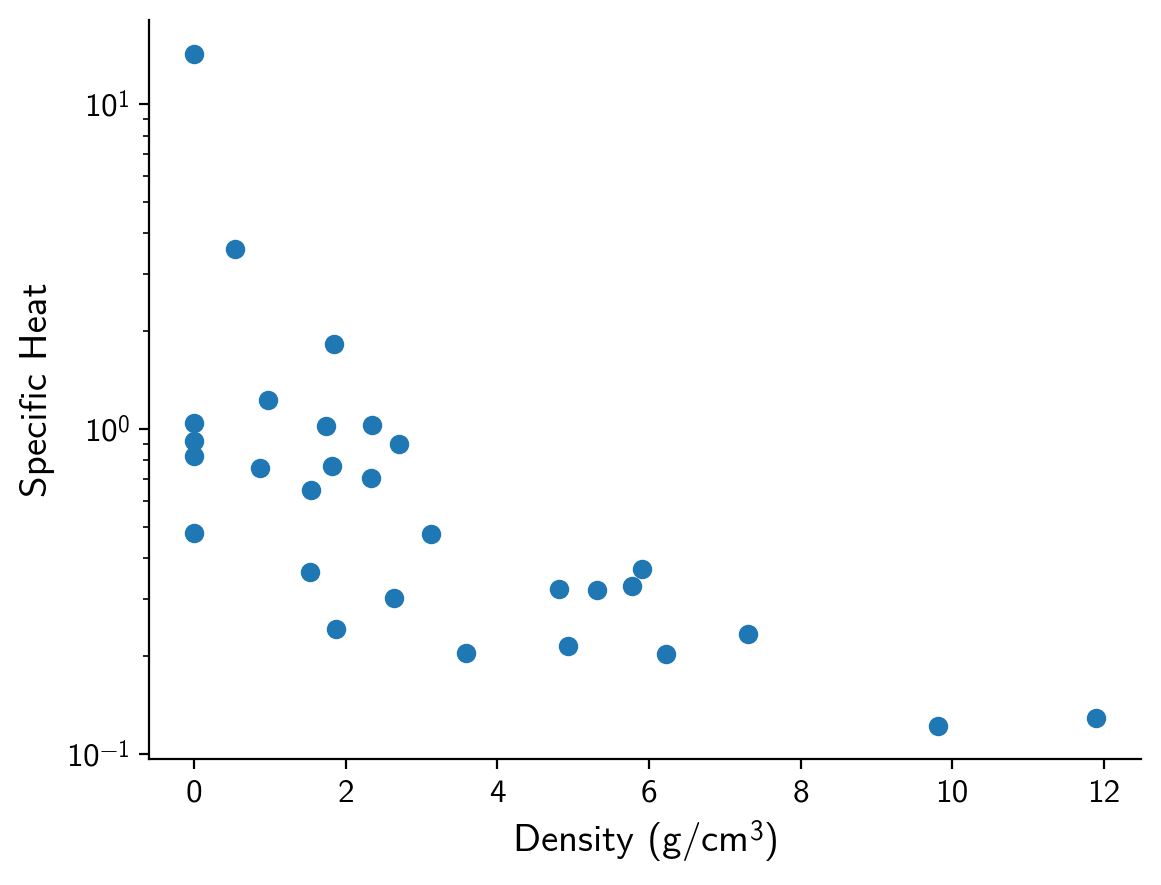

In [8]:
fig, ax = plt.subplots()

_df = df.dropna()

ax.scatter(_df["Density"], _df["SpecificHeat"])

ax.set_xlabel("Density (g/cm$^3$)")
ax.set_ylabel("Specific Heat")

ax.set_yscale("log")

plt.show()

### Running averages

Sometimes, data can be quite noisy if you are dealing with real (or even simulated) data.
In many cases, oscillations, say, in spectra can make the final visualization tricky or unrealistic.
For instance, the plot below is an example of a simulated infrared spectrum that showcases these oscillations in the peak intensity

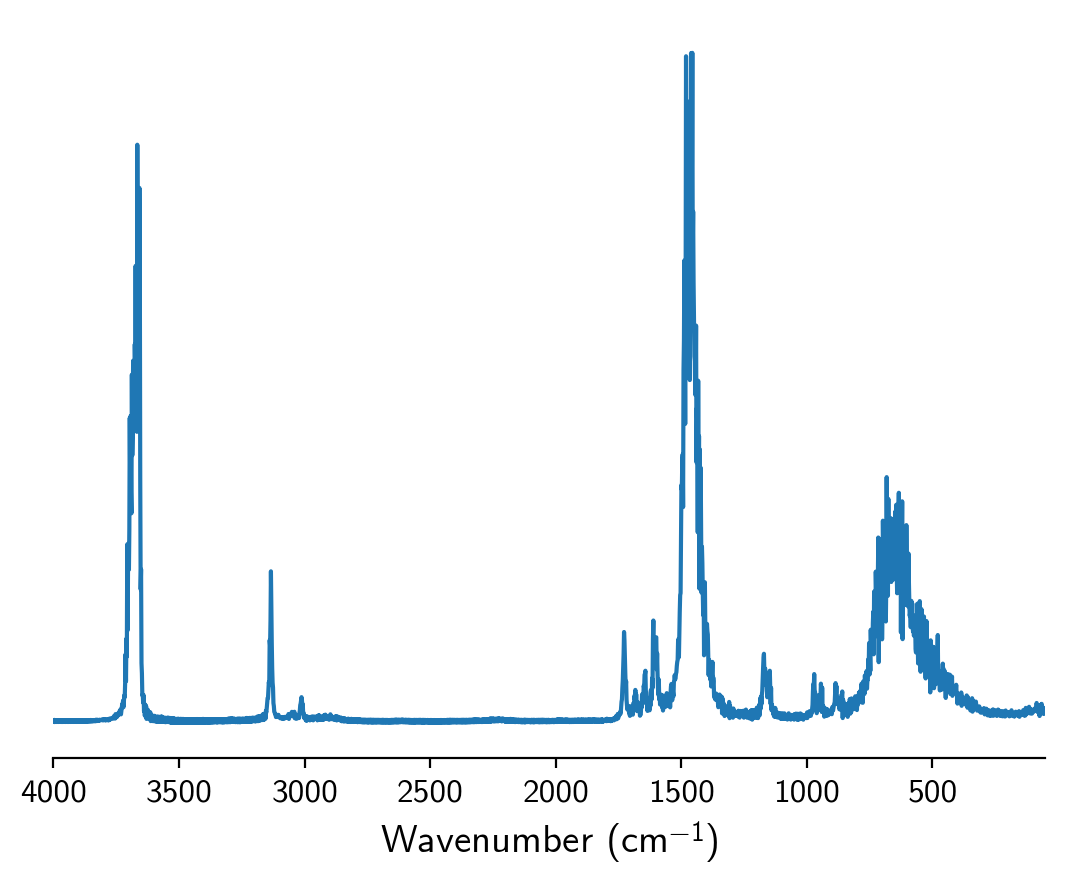

In [9]:
ir = pd.read_csv(f"{ROOT}/data/ir-ethanol.csv", index_col=0)

fig, ax = plt.subplots()

ax.plot(ir["w"], ir["IR"])
ax.spines["left"].set_visible(False)
ax.set_xlim(4000, 50)

ax.set_yticks([])

ax.set_xlabel("Wavenumber (cm$^{-1}$)")
plt.show()

One alternative to remove the high-frequency oscillations in the data is to simply apply a low-pass filter, or even simpler, perform a moving average:

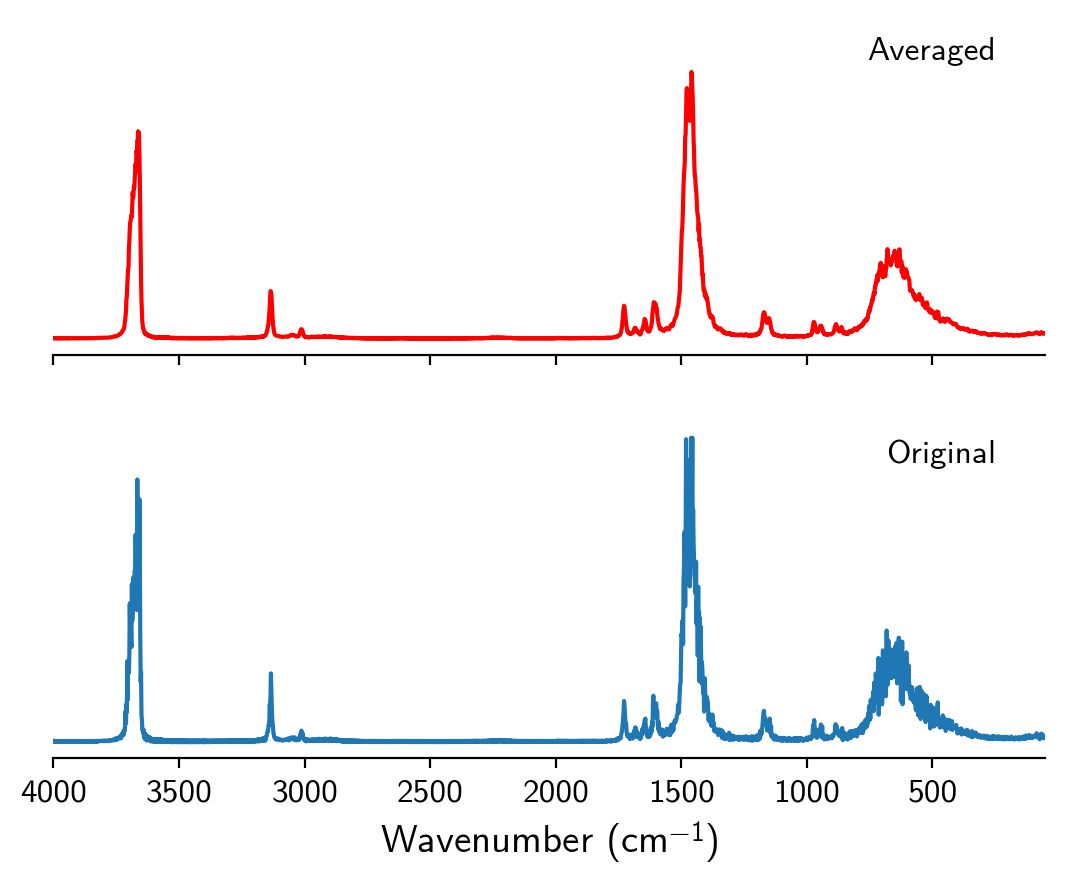

In [10]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)

avg = ir.rolling(window=5).mean()

ax = axs[0]
ax.plot(avg["w"], avg["IR"], "r-")
ax.spines["left"].set_visible(False)

ax.annotate("Averaged", (0.95, 0.95), xycoords="axes fraction", ha="right", va="top")

ax = axs[1]
ax.plot(ir["w"], ir["IR"])
ax.spines["left"].set_visible(False)
ax.set_xlim(4000, 50)

ax.annotate("Original", (0.95, 0.95), xycoords="axes fraction", ha="right", va="top")

ax.set_yticks([])

ax.set_xlabel("Wavenumber (cm$^{-1}$)")
plt.show()

When performing this operation, however, be careful: you are changing the data.
In this infrared example, we have a good reason to apply this transformation (i.e., an artifact of the sampling and Fourier transform creates the oscillatory behavior), but some datasets cannot be filtered in this way without loss of information.

**Bottom line:** Before applying any kind of data transformation, make sure you know what you are doing!

## Basic statistical analysis

### Correlations

Correlation quantifies the strength and direction of the linear relationship between two variables.
Instead of simply plotting them in a scatter plot, we can quantify how the two variables are related using correlation coefficients.
For instance, the Pearson correlation coefficient (r) ranges from -1 to +1, where -1 indicates a perfect negative linear relationship, +1 indicates a perfect positive linear relationship, and 0 indicates no linear relationship.

For instance, in the previous visualizations, we observed how two variables may be strongly correlated:

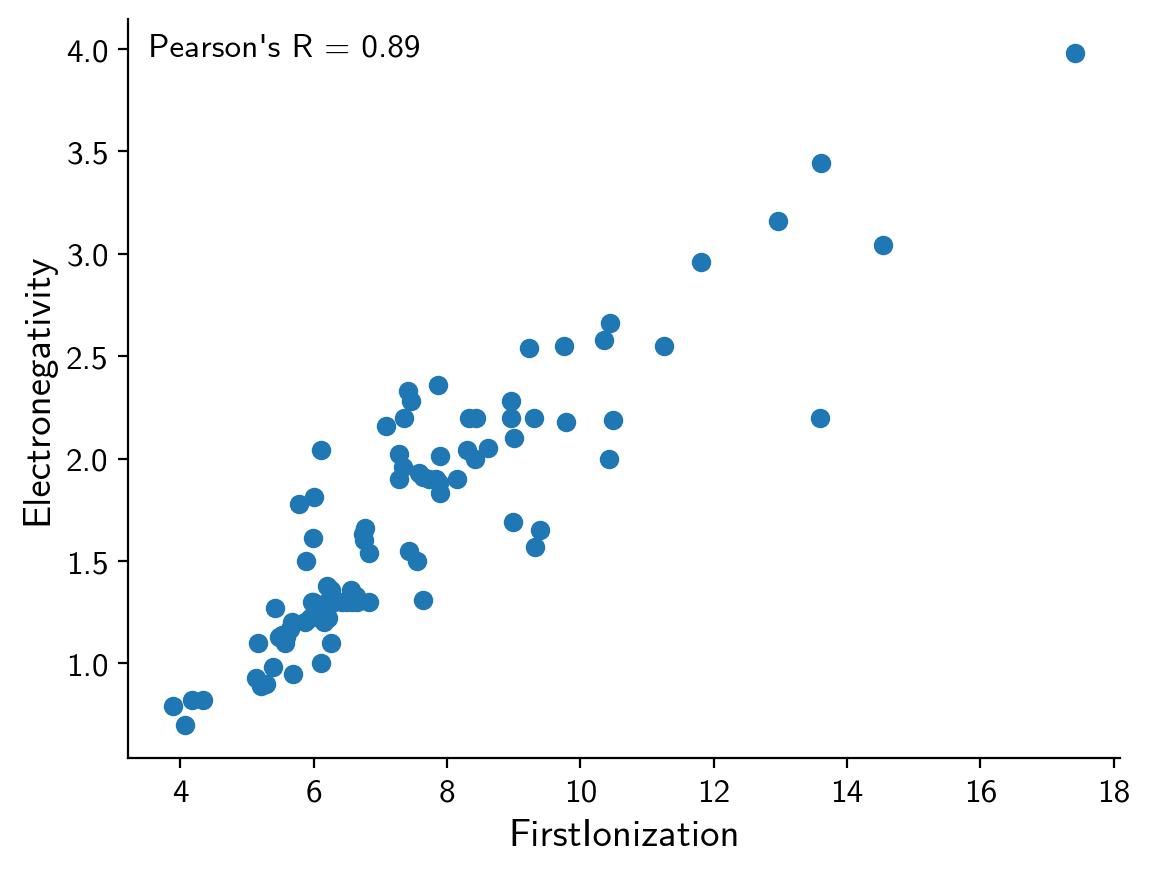

In [11]:
label_x, label_y = "FirstIonization", "Electronegativity"

x, y = df[[label_x, label_y]].dropna().values.T

corr = stats.pearsonr(x, y)

fig, ax = plt.subplots()

ax.scatter(x, y)

ax.set_xlabel(label_x)
ax.set_ylabel(label_y)

ax.annotate(f"Pearson's R = {corr.statistic:0.2f}", (0.02, 0.95), xycoords="axes fraction")
plt.show()

Other variables may have some correlation, but not so strong as the other one:

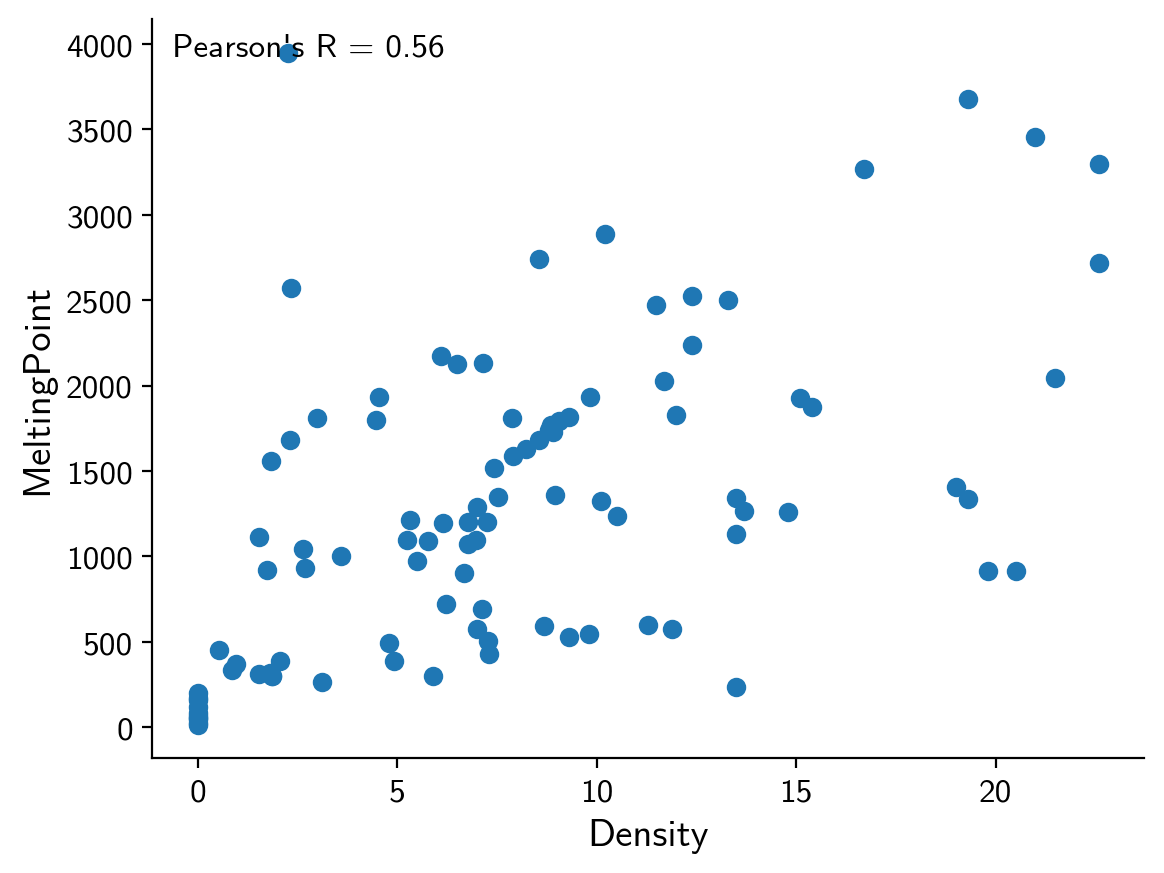

In [12]:
label_x, label_y = "Density", "MeltingPoint"

x, y = df[[label_x, label_y]].dropna().values.T

corr = stats.pearsonr(x, y)

fig, ax = plt.subplots()

ax.scatter(x, y)

ax.set_xlabel(label_x)
ax.set_ylabel(label_y)

ax.annotate(f"Pearson's R = {corr.statistic:0.2f}", (0.02, 0.95), xycoords="axes fraction")
plt.show()

Finally, some may have little to no correlation at all:

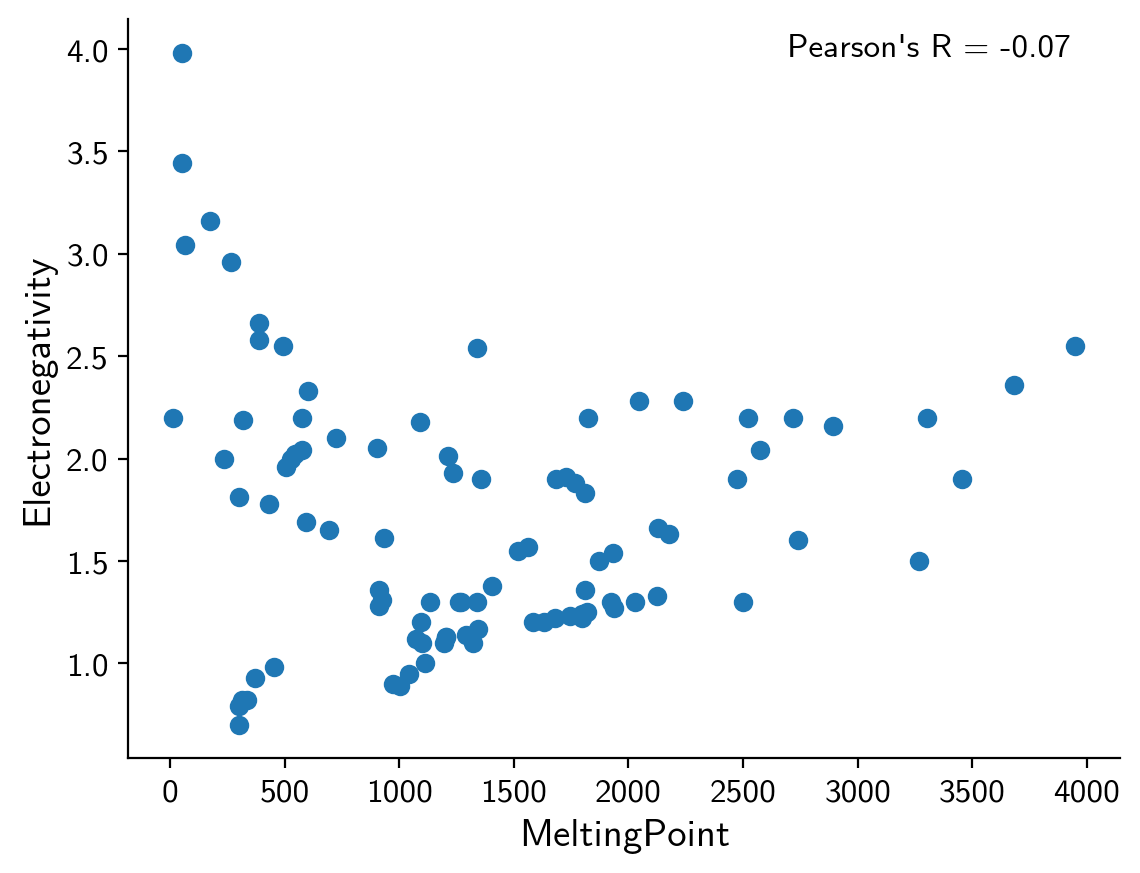

In [13]:
label_x, label_y = "MeltingPoint", "Electronegativity"

x, y = df[[label_x, label_y]].dropna().values.T

corr = stats.pearsonr(x, y)

fig, ax = plt.subplots()

ax.scatter(x, y)

ax.set_xlabel(label_x)
ax.set_ylabel(label_y)

ax.annotate(f"Pearson's R = {corr.statistic:0.2f}", (0.95, 0.95), ha="right", xycoords="axes fraction")
plt.show()

To make the analysis easier, we can consolidate these results in a correlation matrix:

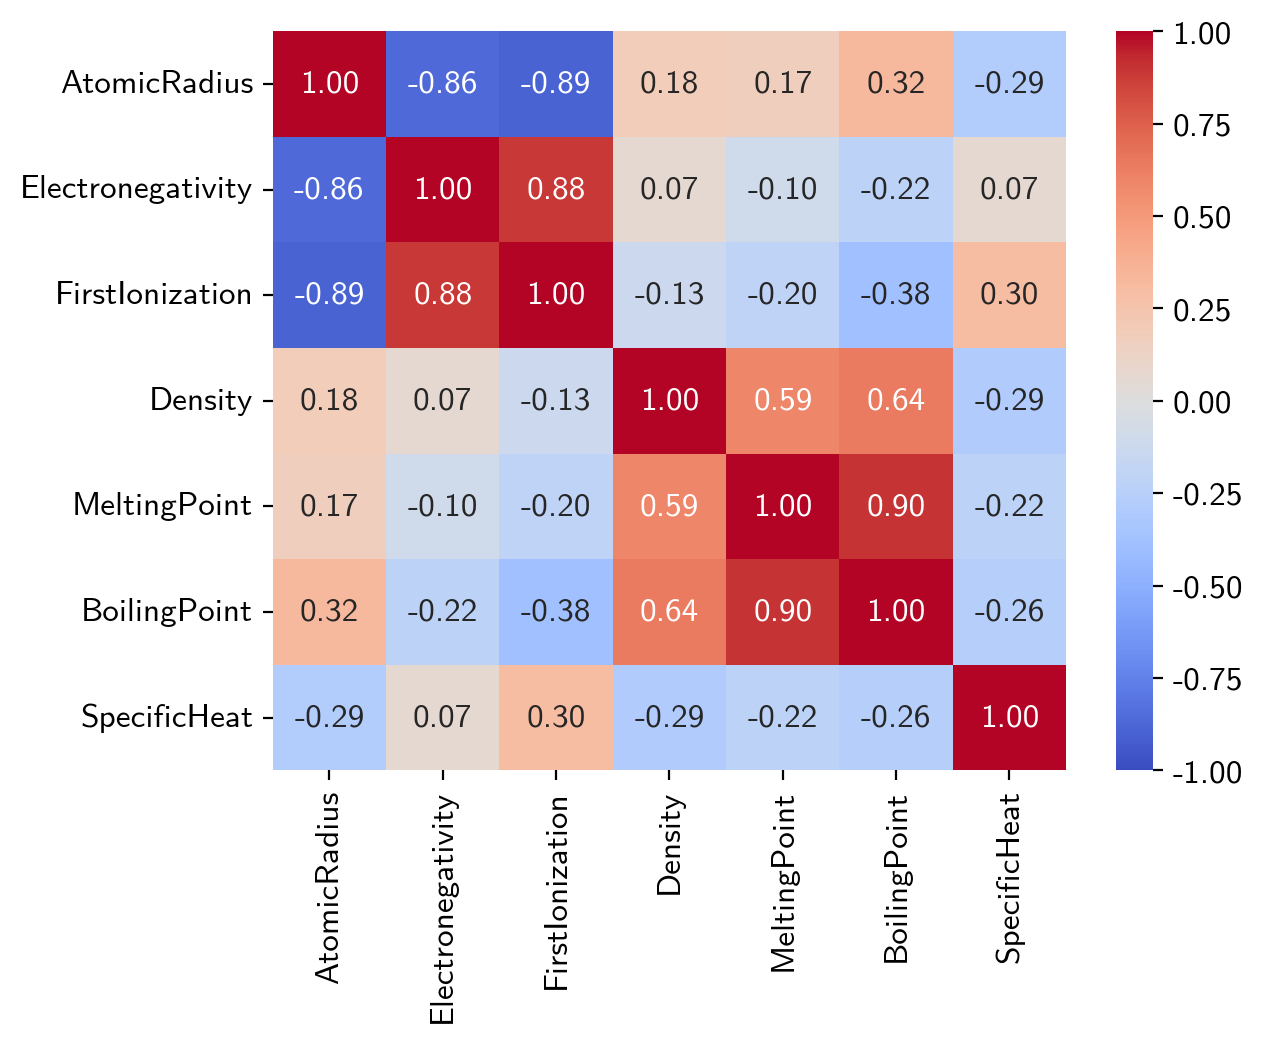

In [14]:
props = ['AtomicRadius', 'Electronegativity', 'FirstIonization', 'Density', 'MeltingPoint',
       'BoilingPoint', 'SpecificHeat']

matrix = df[props].dropna().corr()

sns.heatmap(matrix, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt="0.2f")

plt.show()

### Types of correlation coefficient

The Pearson correlation coefficient is not the only way to compute the correlation between the variables.
Other statistics are also used to quantify how similar are two variables.
This is a quick summary of some of the widely used coefficients:

**Pearson Correlation (r):**

- Measures the strength and direction of linear relationships
- Sensitive to outliers and requires normally distributed variables
- Assumes a linear relationship between variables
- Values range from -1 to +1

**Spearman Correlation (ρ):**

- Measures monotonic relationships (whether variables increase/decrease together, regardless of rate).
- Based on ranked values, making it more resistant to outliers.
- Does not assume linearity or normal distribution.
- Values range from -1 to +1.

**Coefficient of Determination (R²):**

- Represents the proportion of variance in the dependent variable explained by the independent variables.
- Can be interpreted as a percentage, but the result can be negative.
- For simple linear regression, R² is the square of the Pearson correlation coefficient.

For instance, if the matrix above had been computed with the Spearman's correlation coefficient instead of the Pearson one, it would be slightly different:

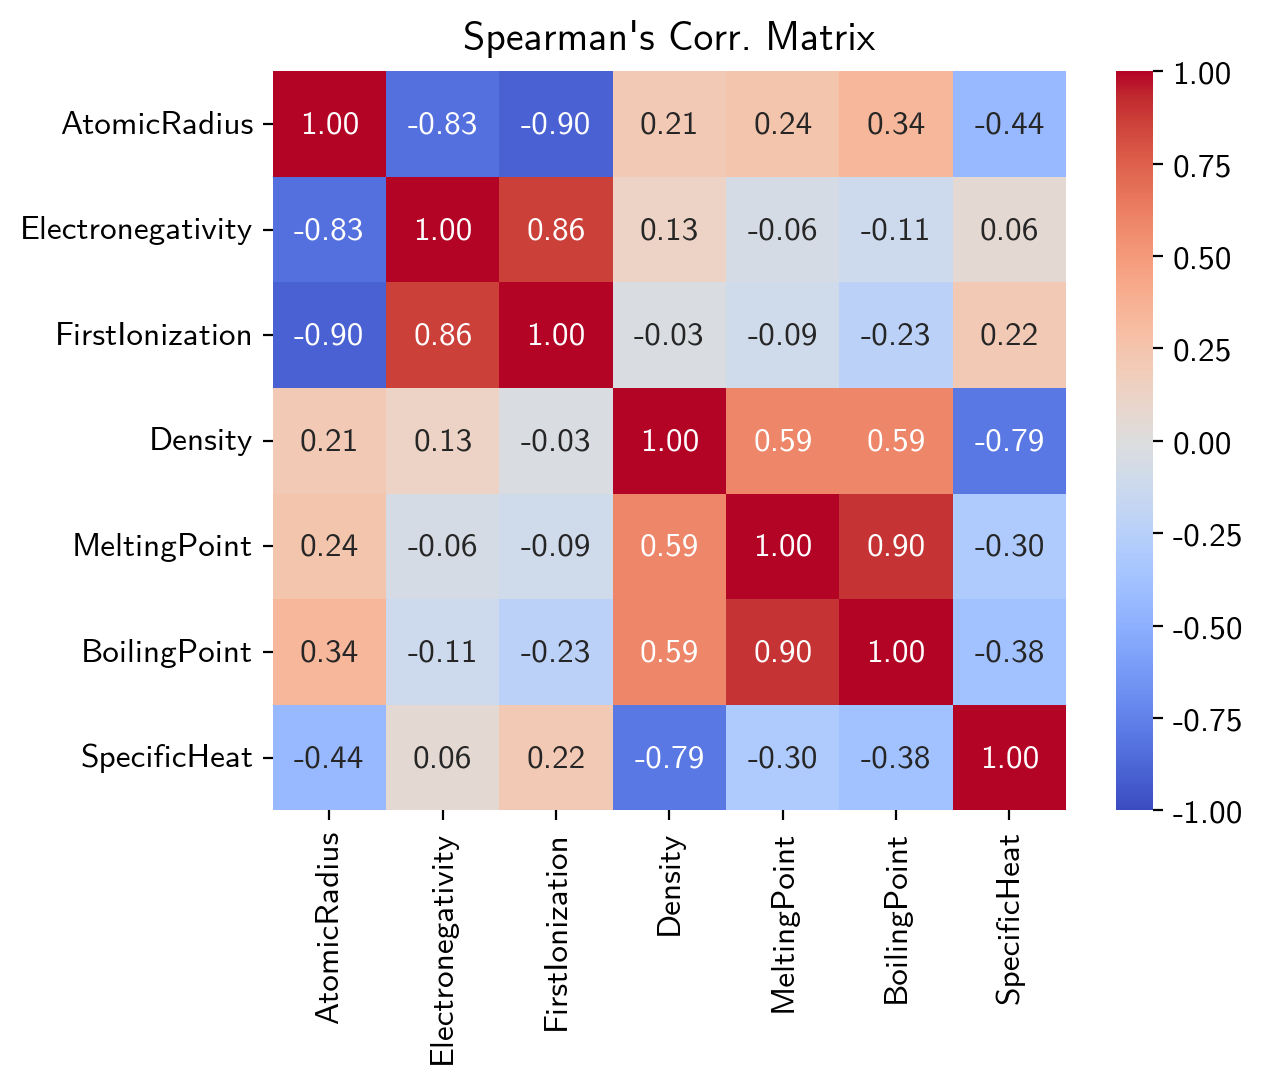

In [15]:
props = ['AtomicRadius', 'Electronegativity', 'FirstIonization', 'Density', 'MeltingPoint',
       'BoilingPoint', 'SpecificHeat']

matrix = df[props].dropna().corr(method="spearman")

ax = sns.heatmap(matrix, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt="0.2f")

ax.set_title("Spearman's Corr. Matrix")
plt.show()

### Correlation is not causation

Correlation merely identifies patterns of co-occurrence between variables, NOT the underlying causal mechanisms.
Two variables may move together due to pure coincidence, indirect relationships through unmeasured variables (confounders), reverse causation, or complex feedback loops.

For example, ice cream sales and drowning incidents might show strong positive correlation, not because ice cream causes drowning, but because both ice cream consumption and swimming on pools/beaches increase during warmer weather - the actual causal factor.

The establishment of causation requires additional evidence beyond statistical correlation, typically involving controlled experiments, temporal precedence (cause precedes effect), and theoretical plausibility. Consider the following visualization that demonstrates how misleading correlations can be:

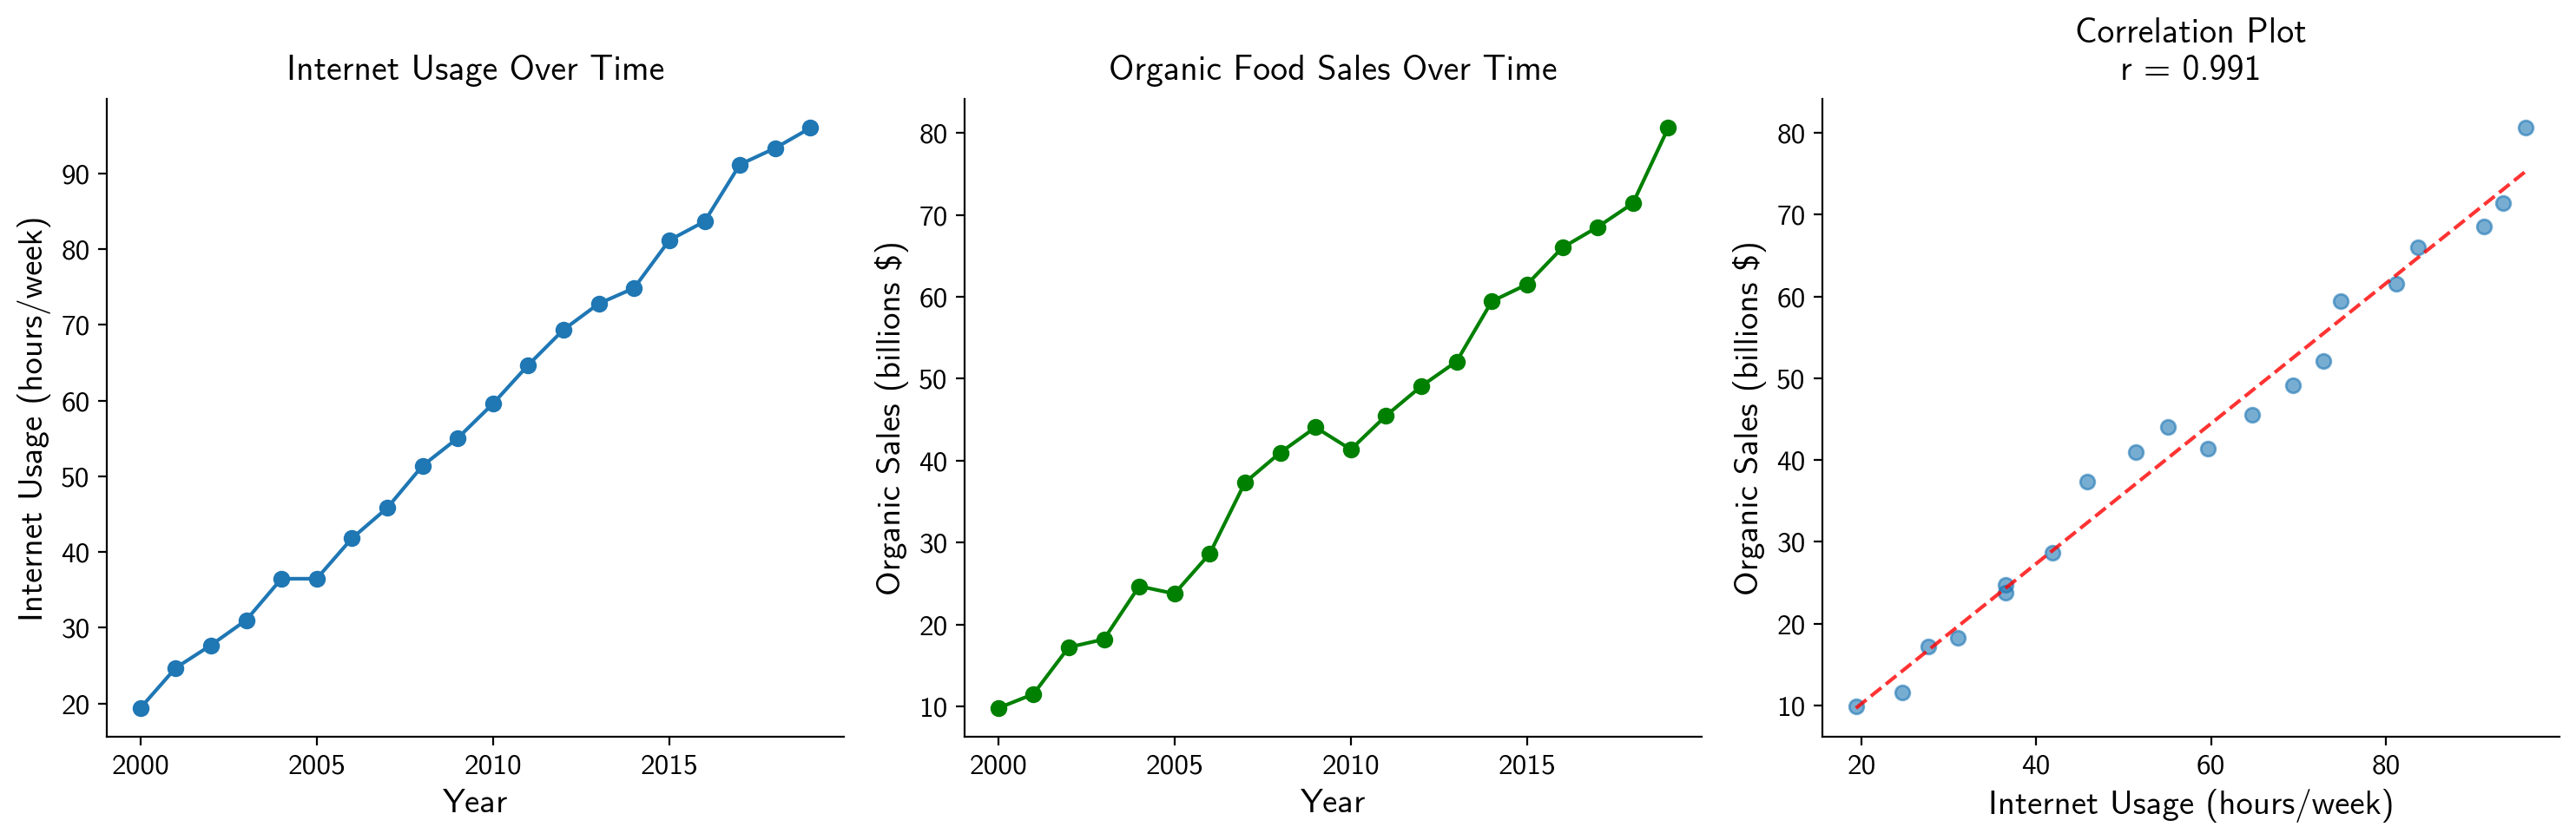

In [16]:
np.random.seed(15)

years = np.arange(2000, 2020)
internet_usage = 20 + 4 * (years - 2000) + np.random.normal(0, 2, len(years))
organic_sales = 10 + 3.5 * (years - 2000) + np.random.normal(0, 2, len(years))

correlation = stats.pearsonr(internet_usage, organic_sales)[0]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

ax = axs[0]
ax.plot(years, internet_usage, marker='o')
ax.set_title('Internet Usage Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Internet Usage (hours/week)')

ax = axs[1]
ax.plot(years, organic_sales, marker='o', color='green')
ax.set_title('Organic Food Sales Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Organic Sales (billions $)')

ax = axs[2]
ax.scatter(internet_usage, organic_sales, alpha=0.6)
ax.set_title(f'Correlation Plot\nr = {correlation:.3f}')
ax.set_xlabel('Internet Usage (hours/week)')
ax.set_ylabel('Organic Sales (billions $)')

z = np.polyfit(internet_usage, organic_sales, 1)
p = np.poly1d(z)
ax.plot(internet_usage, p(internet_usage), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

The visualizations demonstrate two important cases: First, a spurious correlation between internet usage and organic food sales, which both increase over time but aren't causally related. Second, a scenario where two variables appear correlated due to a common cause (confounding variable). These examples highlight why we must be cautious in inferring causation from correlation and emphasize the importance of controlled experiments and careful consideration of potential confounding variables in establishing causal relationships.

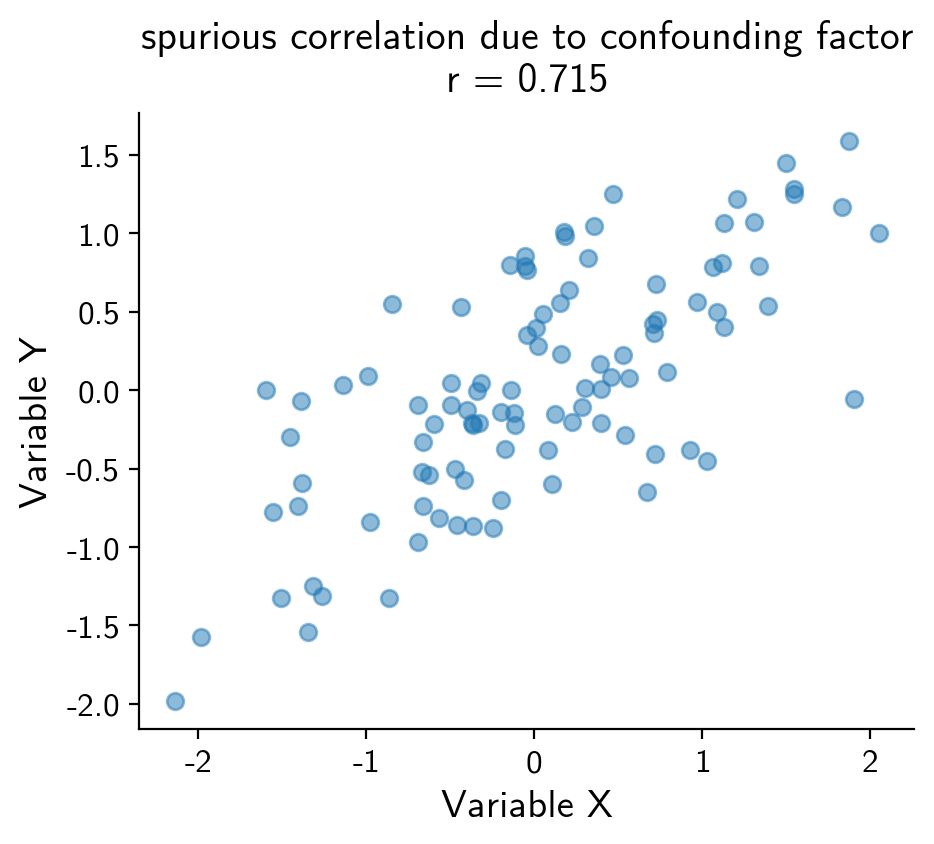

In [17]:
np.random.seed(60)

z = np.random.normal(0, 1, 100)  # Confounding variable (e.g., economic growth)
x = 0.7 * z + np.random.normal(0, 0.5, 100)  # Variable X influenced by Z
y = 0.6 * z + np.random.normal(0, 0.5, 100)  # Variable Y influenced by Z

spurious_corr = stats.pearsonr(x, y)[0]

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, alpha=0.5)
ax.set_title(f'spurious correlation due to confounding factor\nr = {spurious_corr:.3f}')
ax.set_xlabel('Variable X')
ax.set_ylabel('Variable Y')

plt.show()

## The necessity of plotting data

The use of correlation metrics is extremely useful for the quantification of the results obtained at each stage.
However, metrics alone are not enough to draw conclusions from data.
As an example, the statistician Francis Ascombe created, in 1973, a dataset now known as the "Anscombe's quartet" for which there are four subsets of the data.
All subsets have the same correlation coefficient, but represent completely different data origins.
Let us plot the datasets and understand their origin:

In [18]:
quartet = pd.read_csv(f"{ROOT}/data/anscombe.csv", index_col=0)

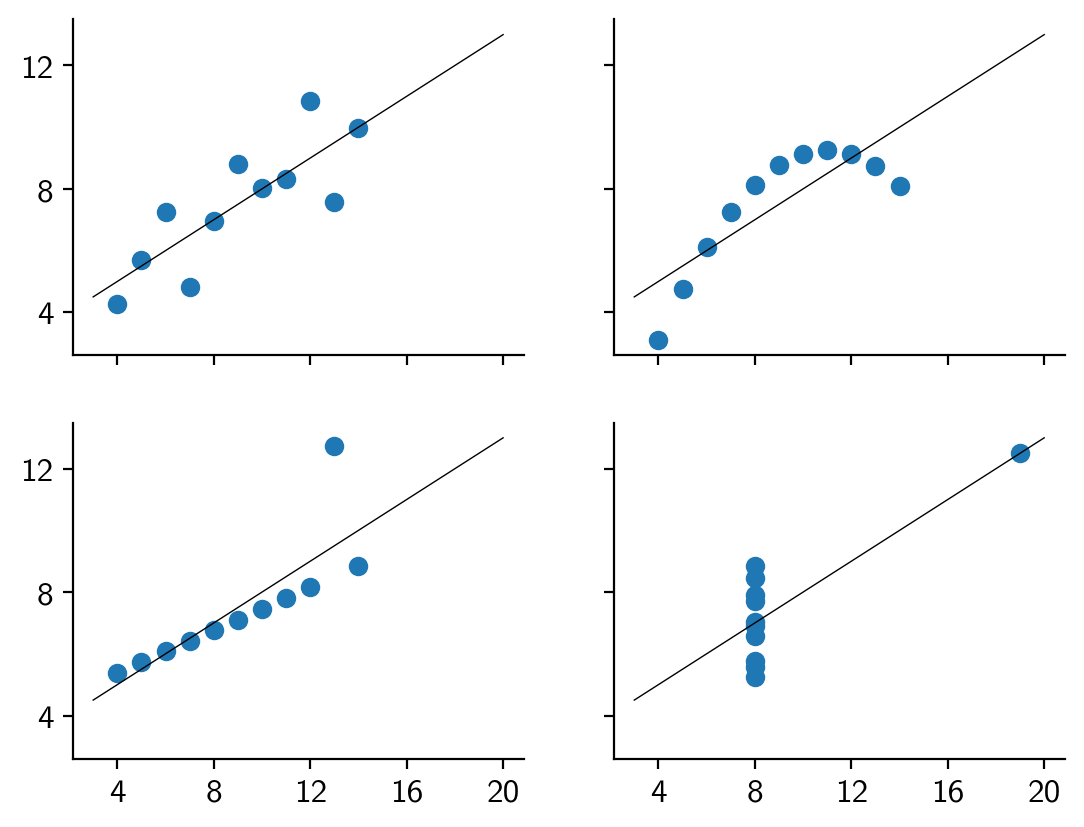

In [19]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)

_x = np.linspace(3, 20)
_y = 3 + 0.5 * _x

for ax, (label, grp) in zip(axs.ravel(), quartet.groupby("dataset")):
    ax.scatter(grp["x"], grp["y"])
    ax.plot(_x, _y, "k-", linewidth=0.5)

ticks = [4, 8, 12, 16, 20]
ax.set_xticks(ticks)
ax.set_yticks(ticks[:3])

plt.show()

Look, for example, at some of the statistics of the dataset:

In [20]:
quartet.groupby("dataset").describe()

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

### Variation: datasaurus

Another variation of the example above is the DataSaurus dataset, which was generated by Justin Matejka and George Fitzmaurice (see https://www.autodesk.com/research/publications/same-stats-different-graphs) and based on the datasaurus set from Alberto Cairo (see http://www.thefunctionalart.com/2016/08/download-datasaurus-never-trust-summary.html).
The premise of this new dataset is the same: showcase how different statistics can be misleading without any data visualization:

In [21]:
dsaurus = pd.read_csv(f"{ROOT}/data/datasaurus.csv")

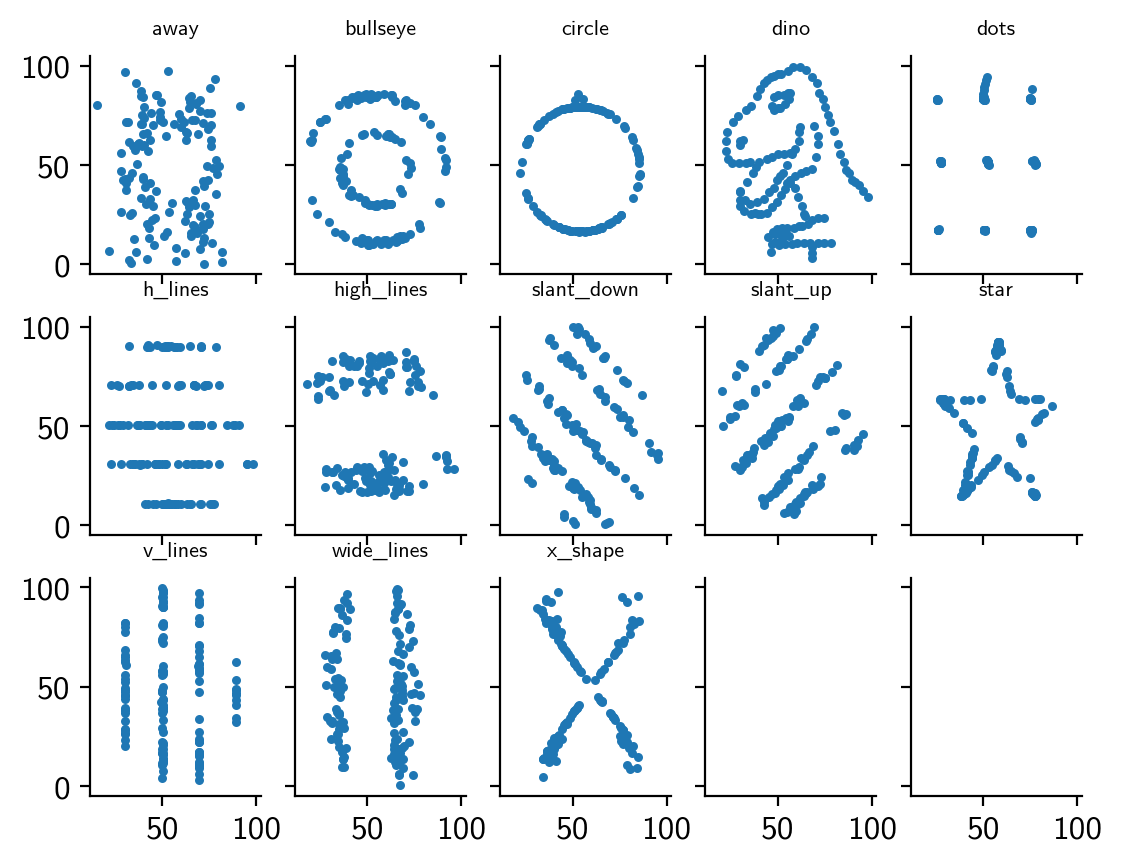

In [22]:
fig, axs = plt.subplots(3, 5, sharex=True, sharey=True)

_x = np.linspace(3, 20)
_y = 3 + 0.5 * _x

for ax, (label, grp) in zip(axs.ravel(), dsaurus.groupby("dataset")):
    ax.scatter(grp["x"], grp["y"], s=5)
    ax.set_title(label, fontsize=8)

# ticks = [4, 8, 12, 16, 20]
# ax.set_xticks(ticks)
# ax.set_yticks(ticks[:3])

plt.show()

In [23]:
dsaurus.groupby("dataset").describe()

x                                                         \
            count       mean        std        min        25%        50%   
dataset                                                                    
away        142.0  54.266100  16.769825  15.560750  39.724115  53.340296   
bullseye    142.0  54.268730  16.769239  19.288205  41.627968  53.842088   
circle      142.0  54.267320  16.760013  21.863581  43.379116  54.023213   
dino        142.0  54.263273  16.765142  22.307700  44.102600  53.333300   
dots        142.0  54.260303  16.767735  25.443526  50.359707  50.976768   
h_lines     142.0  54.261442  16.765898  22.003709  42.293828  53.069678   
high_lines  142.0  54.268805  16.766704  17.893499  41.535981  54.168689   
slant_down  142.0  54.267849  16.766759  18.109472  42.890931  53.135159   
slant_up    142.0  54.265882  16.768853  20.209778  42.810866  54.261345   
star        142.0  54.267341  16.768959  27.024603  41.034210  56.534732   
v_lines     142.0  54.269927  16.769959  30.449654  49.964506  50.362890   
wide_lines  142.0  54.266916  16.770000  27.439632  35.522449  64.550226   
x_shape     142.0  54.260150  16.769958  31.106867  40.091656  47.136458   

                                      y                                   \
                  75%        max  count       mean        std        min   
dataset                                                                    
away        69.146597  91.639961  142.0  47.834721  26.939743   0.015119   
bullseye    64.798900  91.735539  142.0  47.830823  26.935727   9.691547   
circle      64.972672  85.664761  142.0  47.837717  26.930036  16.326546   
dino        64.743600  98.205100  142.0  47.832253  26.935403   2.948700   
dots        75.197363  77.954435  142.0  47.839829  26.930192  15.771892   
h_lines     66.768274  98.288123  142.0  47.830252  26.939876  10.463915   
high_lines  63.952667  96.080519  142.0  47.835450  26.939998  14.913962   
slant_down  64.469989  95.593416  142.0  47.835896  26.936105   0.303872   
slant_up    64.488010  95.260528  142.0  47.831496  26.938608   5.645777   
star        68.711493  86.435897  142.0  47.839545  26.930275  14.365590   
v_lines     69.504068  89.504851  142.0  47.836988  26.937684   2.734760   
wide_lines  67.453672  77.915874  142.0  47.831602  26.937902   0.217006   
x_shape     71.856923  85.446186  142.0  47.839717  26.930002   4.577661   

                                                        
                  25%        50%        75%        max  
dataset                                                 
away        24.625892  47.535269  71.803148  97.475771  
bullseye    26.244735  47.382937  72.532852  85.876229  
circle      18.349610  51.025022  77.782382  85.578134  
dino        25.288450  46.025600  68.525675  99.487200  
dots        17.107141  51.299291  82.881589  94.249328  
h_lines     30.479911  50.473527  70.349471  90.458936  
high_lines  22.920843  32.499203  75.940022  87.152208  
slant_down  27.840858  46.401314  68.439430  99.644179  
slant_up    24.756248  45.292238  70.855844  99.579591  
star        20.374135  50.110554  63.548584  92.214989  
v_lines     22.752884  47.113616  65.845391  99.694680  
wide_lines  24.346941  46.279331  67.568127  99.283764  
x_shape     23.470809  39.876211  73.609634  97.837615

## Bottom line: data science is about data, but also the scientist

In this lecture, we have seen how data science relies on data, but also on the scientists' judgement to correctly interpret the results.
The examples where the data is related to materials science and chemistry are relevant for a number of cases, including those where data interpretability and fidelity would be lost with the wrong visualizations.
On the other hand, the periodic table is one of the best examples of good data visualization: by organizing all the known information in a useful chart, it has perpetuated itself over time, and beautifully arranges the data from chemical elements.